In [1]:
# import modules & set up logging
import logging
import os

import numpy as np

import gensim
from gensim.models import word2vec

import jieba.analyse
import jieba

/opt/anaconda3/envs/py3.12.11/lib/python3.12/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# set up logging
# logging.basicConfig() 这是 logging 模块的 基础配置函数，用于初始化日志系统。
"""
字段	            含义       等级	    说明
%(asctime)s	    日志时间    DEBUG	调试信息
%(levelname)s	日志级别    INFO	    一般信息
%(message)s	    日志内容    WARNING	警告
                           ERROR	错误
						   CRITICAL	严重错误
level = logging.INFO
意思是：只输出 INFO 级别及以上的日志a
"""
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

In [3]:
sentence_file_path = './datas/in_the_name_of_people.txt'
word_file_path = './datas/cut_words_of_in_the_name_of_people.txt'
model_file_path1 = './datas/gensim_word2vec1.w2v'
model_file_path2 = './datas/gensim_word2vec2.bin'
model_file_path3 = './datas/gensim_word2vec3_{}.npy'

## 一、分词

In [4]:
# 人民的名义 小说分词  (防止词被拆开)
jieba.suggest_freq('沙瑞金',True)
jieba.suggest_freq('田国富',True)
jieba.suggest_freq('高育良',True)
jieba.suggest_freq('侯亮平',True)
jieba.suggest_freq('钟小艾', True)
jieba.suggest_freq('陈岩石', True)
jieba.suggest_freq('欧阳菁', True)
jieba.suggest_freq('易学习', True)
jieba.suggest_freq('王大路', True)
jieba.suggest_freq('蔡成功', True)
jieba.suggest_freq('孙连城', True)
jieba.suggest_freq('季昌明', True)
jieba.suggest_freq('丁义珍', True)
jieba.suggest_freq('郑西坡', True)
jieba.suggest_freq('赵东来', True)
jieba.suggest_freq('高小琴', True)
jieba.suggest_freq('赵瑞龙', True)
jieba.suggest_freq('林华华', True)
jieba.suggest_freq('陆亦可', True)
jieba.suggest_freq('刘新建', True)
jieba.suggest_freq('刘庆祝', True)
jieba.suggest_freq('京州市', True)
jieba.suggest_freq('副市长', True)
jieba.suggest_freq('赵德汉',True)
jieba.suggest_freq('H大学',True)
jieba.suggest_freq('H省',True)
jieba.suggest_freq('政法系', True)
jieba.suggest_freq(('哥', '求'), True)

word_cnt = {}
total_word_cnt = 0

with open(word_file_path,'w', encoding='utf-8') as writer:
    with open(sentence_file_path, 'r', encoding='utf-8') as reader:
        # 加载所有数据
        content = reader.read()

        # 分词
        content = jieba.lcut(content)

        # 统计各个单词出现的次数
        for word in content:
            word_cnt[word] = word_cnt.get(word, 0) + 1
            total_word_cnt += 1

        # 合并结果
        result = ' '.join(content)

        # 结果输出
        writer.write(result)
print("Done!!!")

Building prefix dict from the default dictionary ...
2026-03-13 14:21:38,427 : DEBUG : Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/71/13txvqn51x38p9qbcjvs2h940000gn/T/jieba.cache
2026-03-13 14:21:38,429 : DEBUG : Loading model from cache /var/folders/71/13txvqn51x38p9qbcjvs2h940000gn/T/jieba.cache
Loading model cost 0.385 seconds.
2026-03-13 14:21:38,814 : DEBUG : Loading model cost 0.385 seconds.
Prefix dict has been built successfully.
2026-03-13 14:21:38,815 : DEBUG : Prefix dict has been built successfully.


Done!!!


In [6]:
## 计算单词的词频(获取最多的十个)

word_freq = []
for word in word_cnt.keys():
    word_freq.append([word, word_cnt[word] / total_word_cnt])
sorted_word_freq = sorted(word_freq, key=lambda t: t[1], reverse=True)
sorted_word_freq[:10]

[['，', 0.09016437265722925],
 ['的', 0.033516101629469455],
 [' ', 0.028157802503311808],
 ['。', 0.028033052745385745],
 ['了', 0.02777761276487047],
 ['！', 0.014708590505949375],
 ['：', 0.014435329131444661],
 ['\n', 0.014375924484813202],
 ['？', 0.012564082762553688],
 ['是', 0.011744298639039545]]

## 二、Gensim Word2Vec构建

#### 训练方式一

In [7]:
print(f"针对低频词 -> 删除概率:{max(1 - np.sqrt(0.0001 / 0.0000001), 0)}")
print(f"针对低频词 -> 删除概率:{max(1 - np.sqrt(0.0001 / 0.0001), 0)}")
print(f"针对高频词 -> 删除概率:{max(1 - np.sqrt(0.0001 / 0.00011), 0)}")
print(f"针对高频词 -> 删除概率:{max(1 - np.sqrt(0.0001 / 0.0002), 0)}")
print(f"针对高频词 -> 删除概率:{max(1 - np.sqrt(0.0001 / 0.0011), 0)}")
print(f"针对高频词 -> 删除概率:{max(1 - np.sqrt(0.0001 / 0.02), 0)}")

针对低频词 -> 删除概率:0
针对低频词 -> 删除概率:0.0
针对高频词 -> 删除概率:0.04653741075440765
针对高频词 -> 删除概率:0.2928932188134524
针对高频词 -> 删除概率:0.6984886554222364
针对高频词 -> 删除概率:0.9292893218813453


In [12]:
# 每行数据加载
print(f"文件路径:{word_file_path}")
# 按行读取文本文件 每一行视为一个句子 按空格切分成单词
sentences = word2vec.LineSentence(word_file_path)
# 训练Word2Vec模型
"""
class gensim.models.word2vec.Word2Vec(
    sentences=None, corpus_file=None,
    vector_size=100, alpha=0.025, window=5, min_count=5, max_vocab_size=None,
    sample=0.001, seed=1, workers=3, min_alpha=0.0001,
    sg=0, hs=0, negative=5, ns_exponent=0.75, cbow_mean=1,
    hashfxn=<built-in function hash>, epochs=5,
    null_word=0, trim_rule=None, sorted_vocab=1,
    batch_words=10000, compute_loss=False,
    callbacks=(), comment=None, max_final_vocab=None, shrink_windows=True)

sentences=None,  给定训练数据对应的文本对象
corpus_file=None, 词汇表对应的文件，如果不给定的话，直接采用训练数据构建词典/词汇表
vector_size=100, 期望单词映射的维度大小
alpha=0.025, 学习率
window=5, 窗口大小，窗口大小 = 周边词 + 1
min_count=5, 针对词频小于5的单词直接删除
sample: 0.001 二次重采样时候的系数t --> 在训练前对所有的token进行遍历处理 --> 随机丢弃 --> 单词词频高的被丢弃的可能性就高，词频低的丢弃的可能性就低 ---> 缓解低频词学习/更新少的情况
sg=0, 0表示CBOW、1表示Skip-Gram
hs=0, 0表示负采样 1表示哈夫曼树(层次Softmax)
negative=5, 仅在hs=0的时候生效，负采样的类别数量；当设定为0的时候，表示不进行负采样
ns_exponent=0.75, 负采样过程中，计算词频过程中的系数
cbow_mean=1, 0表示cbow中求和，1表示cbow中求均值

"""
model = word2vec.Word2Vec(sentences,sg=1, hs = 1,min_count = 1,window = 11,vector_size = 100)

2026-03-13 14:37:53,420 : INFO : collecting all words and their counts
2026-03-13 14:37:53,422 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-13 14:37:53,451 : INFO : collected 17863 word types from a corpus of 161146 raw words and 2311 sentences
2026-03-13 14:37:53,452 : INFO : Creating a fresh vocabulary
2026-03-13 14:37:53,474 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 17863 unique words (100.00% of original 17863, drops 0)', 'datetime': '2026-03-13T14:37:53.474559', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'prepare_vocab'}
2026-03-13 14:37:53,475 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 161146 word corpus (100.00% of original 161146, drops 0)', 'datetime': '2026-03-13T14:37:53.475046', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  

文件路径:./datas/cut_words_of_in_the_name_of_people.txt


2026-03-13 14:37:53,779 : INFO : built huffman tree with maximum node depth 17
2026-03-13 14:37:53,837 : INFO : estimated required memory for 17863 words and 100 dimensions: 33939700 bytes
2026-03-13 14:37:53,837 : INFO : resetting layer weights
2026-03-13 14:37:53,844 : INFO : Word2Vec lifecycle event {'update': False, 'trim_rule': 'None', 'datetime': '2026-03-13T14:37:53.844197', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'build_vocab'}
2026-03-13 14:37:53,844 : WARNING : Both hierarchical softmax and negative sampling are activated. This is probably a mistake. You should set either 'hs=0' or 'negative=0' to disable one of them. 
2026-03-13 14:37:53,845 : INFO : Word2Vec lifecycle event {'msg': 'training model with 3 workers on 17863 vocabulary and 100 features, using sg=1 hs=1 sample=0.001 negative=5 window=11 shrink_windows=True', 'datetime': '2026-03-13T14:37

#### 训练方式二

In [13]:
# 每行数据加载
sentences = word2vec.LineSentence(word_file_path)

# 创建Word2Vec模型
model = word2vec.Word2Vec(hs = 1,min_count = 5,window = 5,vector_size = 100)

# 构建词典
model.build_vocab(sentences)

# 模型训练
model.train(sentences, total_examples=model.corpus_count, epochs=5)

2026-03-13 14:45:20,464 : INFO : Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=100, alpha=0.025>', 'datetime': '2026-03-13T14:45:20.464199', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'created'}
2026-03-13 14:45:20,473 : INFO : collecting all words and their counts
2026-03-13 14:45:20,474 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-13 14:45:20,509 : INFO : collected 17863 word types from a corpus of 161146 raw words and 2311 sentences
2026-03-13 14:45:20,509 : INFO : Creating a fresh vocabulary
2026-03-13 14:45:20,516 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 3340 unique words (18.70% of original 17863, drops 14523)', 'datetime': '2026-03-13T14:45:20.516785', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'pl

(477548, 805730)

## 三、Word2Vec应用
- PS: Word2Vec的模型训练完成后，所有的使用操作都是基于单词向量的使用

### 0. 获取Word2Vec模型相关属性

In [14]:
print("【词汇数目】: {}".format(len(model.wv.key_to_index)))
print("【转换的稠密的特征向量维度数目,每个单词转换的向量维度大小】: {}".format(model.wv.vector_size))
print("【单词到id的映射关系】: \n{}".format(model.wv.key_to_index))

【词汇数目】: 3340
【转换的稠密的特征向量维度数目,每个单词转换的向量维度大小】: 100
【单词到id的映射关系】: 
{'，': 0, '的': 1, '。': 2, '了': 3, '！': 4, '：': 5, '？': 6, '是': 7, '他': 8, '我': 9, '你': 10, '说': 11, '侯亮平': 12, '在': 13, '也': 14, '就': 15, '…': 16, '和': 17, '啊': 18, '不': 19, '李达康': 20, '这': 21, '有': 22, '着': 23, '都': 24, '高育良': 25, '把': 26, '蔡成功': 27, '让': 28, '祁同伟': 29, '老师': 30, '要': 31, '还': 32, '上': 33, '—': 34, '又': 35, '一个': 36, '吧': 37, '到': 38, '书记': 39, '呢': 40, '吗': 41, '没': 42, '人': 43, '对': 44, '地': 45, '沙瑞金': 46, '得': 47, '给': 48, '、': 49, '她': 50, '高小琴': 51, '就是': 52, '我们': 53, '不是': 54, '知道': 55, '这个': 56, '去': 57, '很': 58, '来': 59, '自己': 60, '丁义珍': 61, '现在': 62, '好': 63, '陆亦可': 64, '陈海': 65, '同志': 66, '欧阳菁': 67, '想': 68, '那': 69, '他们': 70, '啥': 71, '季昌明': 72, '这么': 73, '被': 74, '道': 75, '怎么': 76, '您': 77, '高': 78, '局长': 79, '嘛': 80, '会': 81, '你们': 82, '能': 83, '但': 84, '做': 85, '起来': 86, '没有': 87, '走': 88, '一': 89, '谁': 90, '什么': 91, '向': 92, '却': 93, '还是': 94, '大风': 95, '过': 96, '看': 97, '可': 98, '里': 99, '

### 1. 获取相似度最高的K个演员

In [15]:
# 夹角余弦相似度
req_count = 10
for (word, sim) in model.wv.similar_by_word('沙瑞金', topn =100):
    if len(word)==3:  # 为了过滤一下
        req_count -= 1
        print(word, sim)
        if req_count == 0:
            break

高育良 0.9208099842071533
季昌明 0.8847433924674988
李达康 0.8302856683731079
田国富 0.8295099139213562
易学习 0.8259953260421753
谢谢您 0.8161908388137817
吴春林 0.8138570189476013
祁同伟 0.7901405096054077
赵立春 0.7888982892036438
笑了笑 0.7821319103240967


In [16]:
# 夹角余弦相似度
req_count = 10
for (word, sim) in model.wv.similar_by_word('沙瑞金', topn =100):
    if len(word)==4:  # 为了过滤一下
        req_count -= 1
        print(word, sim)
        if req_count == 0:
            break

痛心疾首 0.7897986173629761
直截了当 0.7630192637443542
话里有话 0.762587308883667
不依不饶 0.7599887251853943


In [17]:
# 词性标注模块
import jieba.posseg as pseg

jieba.add_word('沙瑞金',10,'nr')
jieba.add_word('田国富',10,'nr')
jieba.add_word('高育良',10,'nr')
jieba.add_word('侯亮平',10,'nr')
jieba.add_word('钟小艾', 10,'nr')
jieba.add_word('陈岩石', 10,'nr')
jieba.add_word('欧阳菁', 10,'nr')
jieba.add_word('易学习', 10,'nr')
jieba.add_word('王大路', 10,'nr')
jieba.add_word('蔡成功', 10,'nr')
jieba.add_word('孙连城', 10,'nr')
jieba.add_word('季昌明', 10,'nr')
jieba.add_word('丁义珍', 10,'nr')
jieba.add_word('郑西坡', 10,'nr')
jieba.add_word('赵东来', 10,'nr')
jieba.add_word('高小琴', 10,'nr')
jieba.add_word('赵瑞龙', 10,'nr')
jieba.add_word('林华华', 10,'nr')
jieba.add_word('陆亦可', 10,'nr')
jieba.add_word('刘新建', 10,'nr')
jieba.add_word('刘庆祝', 10,'nr')
jieba.add_word('京州市', 10,'nr')
jieba.add_word('副市长', 10,'nr')
jieba.add_word('赵德汉',10,'nr')
jieba.add_word("谢谢您", None, "o")


tmp01 = model.wv.similar_by_word('沙瑞金', topn=100)
tmp01 = dict(tmp01)
for k in tmp01.keys():
    jieba.suggest_freq(k, True)
tmp02 = ' '.join(list(tmp01.keys()))
words = pseg.lcut(tmp02)
for word,flag in words:
    if flag == 'nr':
        print(word, tmp01[word])


高育良 0.9208099842071533
季昌明 0.8847433924674988
田国富 0.8295099139213562
易学习 0.8259953260421753
侯亮平 0.754099428653717
孙书记 0.7429495453834534
梁 0.7427688837051392
陈岩石 0.7400695085525513


In [18]:
tmp02

'高育良 感慨 严肃 季昌明 淡然 地说 补充 摆手 李达康 叹息 田国富 易学习 注意 谢谢您 吴春林 指示 插话 汇报 责问 瑞金 很 亮 惊讶 强调 讥讽 怔 祁同伟 痛心疾首 赵立春 激动 冷冷 省委 这位 一脸 季检 看 头 听 做个 猴子 附和 笑了笑 开口 一眼 表态 无奈 高兴 育良 前任 肖检 学长 的话 凑近 向 客气 叹 讷讷 直截了当 话里有话 试探 点头 省级 求援 句 不依不饶 学生 打断 透露 感叹 坚定 挥手 侯亮平 急于 肩膀 老朋友 亲自 争辩 肩头 检察长 便 检讨 忍不住 孙书记 梁 咱高 吴慧芬 貌似 话 摇头 摆 提起 走到 陈岩石 态度 对不起 地问 好看 一下 眉头 介绍'

### 2. 获取单词之间的相似度

In [19]:
# 夹角余弦相似度
print(model.wv.similarity('沙瑞金', '高育良'))

0.92081016


In [20]:
# 夹角余弦相似度
v1 = model.wv.get_vector("沙瑞金")
v2 = model.wv.get_vector("高育良")
np.sum(v1 * v2) / (np.sqrt(np.sum(np.power(v1, 2))) * np.sqrt(np.sum(np.power(v2, 2))))

np.float32(0.92081004)

### 3. 获取单词的词向量

In [21]:
v1 = model.wv.get_vector("提拔")
print(v1.shape)
print(v1)

(100,)
[-1.69211358e-01  3.31198007e-01  5.80146536e-02 -6.50020689e-02
 -2.13680580e-01 -1.58545822e-01 -1.06803971e-04  2.22808555e-01
 -1.41558856e-01 -8.18099827e-02 -2.99058892e-02 -1.15753621e-01
  5.95447719e-02 -3.00266165e-02  5.87775074e-02 -2.26235166e-01
  7.73411468e-02 -2.64199853e-01 -1.60959631e-01 -2.20054865e-01
  4.51368183e-01  1.69238687e-01  3.37877929e-01 -2.11534187e-01
  7.27342963e-02  1.73455596e-01 -7.35258311e-02 -2.33156666e-01
 -1.11244351e-01  1.62868232e-01 -9.29093082e-03 -3.23357061e-02
  3.05769473e-01 -3.37990314e-01  1.84201896e-01  2.40649328e-01
 -3.74683961e-02  1.68459103e-01 -4.80214685e-01 -2.22019181e-01
 -7.09349588e-02 -1.60208881e-01  7.74912760e-02 -8.84560719e-02
  4.17315587e-02 -1.66601062e-01  5.80766797e-02  1.48859084e-01
  1.54508844e-01  3.91673185e-02  1.10664427e-01 -1.94884583e-01
  5.71099436e-03 -5.14397249e-02 -2.19238669e-01 -5.35982102e-03
  7.37750903e-02 -7.07878768e-02 -1.56715989e-01  8.95118415e-02
  1.91179663e-02 -

In [22]:
model.wv['提拔']

array([-1.69211358e-01,  3.31198007e-01,  5.80146536e-02, -6.50020689e-02,
       -2.13680580e-01, -1.58545822e-01, -1.06803971e-04,  2.22808555e-01,
       -1.41558856e-01, -8.18099827e-02, -2.99058892e-02, -1.15753621e-01,
        5.95447719e-02, -3.00266165e-02,  5.87775074e-02, -2.26235166e-01,
        7.73411468e-02, -2.64199853e-01, -1.60959631e-01, -2.20054865e-01,
        4.51368183e-01,  1.69238687e-01,  3.37877929e-01, -2.11534187e-01,
        7.27342963e-02,  1.73455596e-01, -7.35258311e-02, -2.33156666e-01,
       -1.11244351e-01,  1.62868232e-01, -9.29093082e-03, -3.23357061e-02,
        3.05769473e-01, -3.37990314e-01,  1.84201896e-01,  2.40649328e-01,
       -3.74683961e-02,  1.68459103e-01, -4.80214685e-01, -2.22019181e-01,
       -7.09349588e-02, -1.60208881e-01,  7.74912760e-02, -8.84560719e-02,
        4.17315587e-02, -1.66601062e-01,  5.80766797e-02,  1.48859084e-01,
        1.54508844e-01,  3.91673185e-02,  1.10664427e-01, -1.94884583e-01,
        5.71099436e-03, -

In [23]:
# 异常：不存在"小明"这个单词
model.wv.get_vector("小明")

KeyError: "Key '小明' not present"

In [24]:
# 首先判断是否存在单词，如果存在，就返回，否则单词直接过滤
word = "小明"
#word = "李达康"
if word in model.wv:
    print("【向量】:\n{}".format(model.wv[word]))
else:
    print("【单词不存在】!!!")

【单词不存在】!!!


## 四、模型持久化&模型恢复加载

### 方式一：
直接使用save API进行模型持久化

#### 持久化

In [25]:
model.save(model_file_path1)

2026-03-13 14:58:04,481 : INFO : Word2Vec lifecycle event {'fname_or_handle': './datas/gensim_word2vec1.w2v', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2026-03-13T14:58:04.481700', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'saving'}
2026-03-13 14:58:04,483 : INFO : not storing attribute cum_table
2026-03-13 14:58:04,499 : INFO : saved ./datas/gensim_word2vec1.w2v


#### 加载

In [26]:
# 直接基于路径加载
model1 = word2vec.Word2Vec.load(model_file_path1)
print(model1)

v1 = model1.wv.get_vector("提拔")
print(v1.shape)
print(v1)

2026-03-13 14:58:15,786 : INFO : loading Word2Vec object from ./datas/gensim_word2vec1.w2v
2026-03-13 14:58:15,798 : INFO : loading wv recursively from ./datas/gensim_word2vec1.w2v.wv.* with mmap=None
2026-03-13 14:58:15,798 : INFO : setting ignored attribute cum_table to None
2026-03-13 14:58:15,816 : INFO : Word2Vec lifecycle event {'fname': './datas/gensim_word2vec1.w2v', 'datetime': '2026-03-13T14:58:15.816114', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'loaded'}


Word2Vec<vocab=3340, vector_size=100, alpha=0.025>
(100,)
[-1.69211358e-01  3.31198007e-01  5.80146536e-02 -6.50020689e-02
 -2.13680580e-01 -1.58545822e-01 -1.06803971e-04  2.22808555e-01
 -1.41558856e-01 -8.18099827e-02 -2.99058892e-02 -1.15753621e-01
  5.95447719e-02 -3.00266165e-02  5.87775074e-02 -2.26235166e-01
  7.73411468e-02 -2.64199853e-01 -1.60959631e-01 -2.20054865e-01
  4.51368183e-01  1.69238687e-01  3.37877929e-01 -2.11534187e-01
  7.27342963e-02  1.73455596e-01 -7.35258311e-02 -2.33156666e-01
 -1.11244351e-01  1.62868232e-01 -9.29093082e-03 -3.23357061e-02
  3.05769473e-01 -3.37990314e-01  1.84201896e-01  2.40649328e-01
 -3.74683961e-02  1.68459103e-01 -4.80214685e-01 -2.22019181e-01
 -7.09349588e-02 -1.60208881e-01  7.74912760e-02 -8.84560719e-02
  4.17315587e-02 -1.66601062e-01  5.80766797e-02  1.48859084e-01
  1.54508844e-01  3.91673185e-02  1.10664427e-01 -1.94884583e-01
  5.71099436e-03 -5.14397249e-02 -2.19238669e-01 -5.35982102e-03
  7.37750903e-02 -7.07878768e-02

### 方式二：
保存为二进制词向量

#### 持久化

In [27]:
model.wv.save_word2vec_format(model_file_path2, binary=True)

2026-03-13 14:58:46,082 : INFO : storing 3340x100 projection weights into ./datas/gensim_word2vec2.bin


In [28]:
model.wv.save_word2vec_format('./datas/gensim_word2vec2.txt', binary=False) # 以文本方式持久化

2026-03-13 14:59:12,784 : INFO : storing 3340x100 projection weights into ./datas/gensim_word2vec2.txt


#### 加载

In [29]:
# 加载模型
model2 = gensim.models.KeyedVectors.load_word2vec_format(model_file_path2, binary=True)
print(model2)

# 应用模型
v1 = model2.get_vector("提拔")
print(v1.shape)
print(v1)

2026-03-13 14:59:51,487 : INFO : loading projection weights from ./datas/gensim_word2vec2.bin
2026-03-13 14:59:51,503 : INFO : KeyedVectors lifecycle event {'msg': 'loaded (3340, 100) matrix of type float32 from ./datas/gensim_word2vec2.bin', 'binary': True, 'encoding': 'utf8', 'datetime': '2026-03-13T14:59:51.503044', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'load_word2vec_format'}


KeyedVectors<vector_size=100, 3340 keys>
(100,)
[-1.69211358e-01  3.31198007e-01  5.80146536e-02 -6.50020689e-02
 -2.13680580e-01 -1.58545822e-01 -1.06803971e-04  2.22808555e-01
 -1.41558856e-01 -8.18099827e-02 -2.99058892e-02 -1.15753621e-01
  5.95447719e-02 -3.00266165e-02  5.87775074e-02 -2.26235166e-01
  7.73411468e-02 -2.64199853e-01 -1.60959631e-01 -2.20054865e-01
  4.51368183e-01  1.69238687e-01  3.37877929e-01 -2.11534187e-01
  7.27342963e-02  1.73455596e-01 -7.35258311e-02 -2.33156666e-01
 -1.11244351e-01  1.62868232e-01 -9.29093082e-03 -3.23357061e-02
  3.05769473e-01 -3.37990314e-01  1.84201896e-01  2.40649328e-01
 -3.74683961e-02  1.68459103e-01 -4.80214685e-01 -2.22019181e-01
 -7.09349588e-02 -1.60208881e-01  7.74912760e-02 -8.84560719e-02
  4.17315587e-02 -1.66601062e-01  5.80766797e-02  1.48859084e-01
  1.54508844e-01  3.91673185e-02  1.10664427e-01 -1.94884583e-01
  5.71099436e-03 -5.14397249e-02 -2.19238669e-01 -5.35982102e-03
  7.37750903e-02 -7.07878768e-02 -1.567159

In [30]:
# 加载模型
model2 = gensim.models.KeyedVectors.load_word2vec_format('./datas/vectors.bin',
                                                         binary=True)
print(model2)

# 应用模型
v1 = model2.get_vector("酒店")
print(v1.shape)
print(v1)

2026-03-13 14:59:59,096 : INFO : loading projection weights from ./datas/vectors.bin
2026-03-13 14:59:59,123 : INFO : KeyedVectors lifecycle event {'msg': 'loaded (7942, 128) matrix of type float32 from ./datas/vectors.bin', 'binary': True, 'encoding': 'utf8', 'datetime': '2026-03-13T14:59:59.123051', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'load_word2vec_format'}


KeyedVectors<vector_size=128, 7942 keys>
(128,)
[ 0.07507085 -0.06233635 -0.08300601 -0.09476656  0.19525695  0.08683676
  0.267884    0.03470918  0.14521684  0.00294149 -0.02735998 -0.09170757
  0.00139181  0.2421832  -0.09511401  0.0341509   0.0283838   0.32073992
  0.172025    0.20465788  0.05929533  0.07462119 -0.23834492  0.0421031
 -0.0448295  -0.02866336  0.05001667 -0.1257836   0.22431172 -0.0807058
 -0.12493779 -0.05265829  0.13126895  0.15061386 -0.19615541 -0.09053446
 -0.05627611 -0.23135136 -0.01231913 -0.23680945 -0.04299964  0.3667591
 -0.06821534 -0.29599202  0.34265348 -0.04311483 -0.21866152 -0.2495054
 -0.43372962  0.0463162   0.11516414  0.07433167  0.09803177 -0.06165684
 -0.1319202   0.04795204  0.2651979   0.09628078 -0.16381025  0.12577897
  0.11097272 -0.15810862 -0.07860032  0.08296187  0.12618895  0.28030068
 -0.00506122  0.05640052  0.11889897 -0.11027029 -0.14830197 -0.00842615
  0.01188814  0.19347009  0.00282715 -0.3220406   0.22365303 -0.23093392
 -0.418

### 方式三：
直接使用NumPy API保存词向量信息

#### 持久化

In [31]:
# 获取词向量
norm_word_embeddings = model.wv.get_normed_vectors()  # L2-norm归一化转换后的单词向量
word_embeddings = model.wv.vectors  # 归一化转换前的单词向量
# 获取词典(词典到idx的映射)
vocab_2_index = list(map(lambda k: (k, model.wv.key_to_index[k]), model.wv.key_to_index))
print(np.shape(norm_word_embeddings), np.shape(word_embeddings), np.shape(vocab_2_index))
# 数据保存
np.save(model_file_path3.format("norm_embedding"), norm_word_embeddings)
np.save(model_file_path3.format("embedding"), word_embeddings)
np.save(model_file_path3.format("vocab_2_index"), vocab_2_index)

(3340, 100) (3340, 100) (3340, 2)


#### 加载

In [32]:
# 加载数据
norm_word_embeddings = np.load(model_file_path3.format("norm_embedding"))
word_embeddings = np.load(model_file_path3.format("embedding"))
vocab_2_index = np.load(model_file_path3.format("vocab_2_index"))

# 字典转换
vocab_2_index = dict(map(lambda t:(t[0], int(t[1])), vocab_2_index))

# 获取数据
word = "提拔"
index = vocab_2_index[word] # 将单词转换为id
v1 = word_embeddings[index] # 获取id对应的词向量
print(v1.shape)
print(v1)

(100,)
[-1.69211358e-01  3.31198007e-01  5.80146536e-02 -6.50020689e-02
 -2.13680580e-01 -1.58545822e-01 -1.06803971e-04  2.22808555e-01
 -1.41558856e-01 -8.18099827e-02 -2.99058892e-02 -1.15753621e-01
  5.95447719e-02 -3.00266165e-02  5.87775074e-02 -2.26235166e-01
  7.73411468e-02 -2.64199853e-01 -1.60959631e-01 -2.20054865e-01
  4.51368183e-01  1.69238687e-01  3.37877929e-01 -2.11534187e-01
  7.27342963e-02  1.73455596e-01 -7.35258311e-02 -2.33156666e-01
 -1.11244351e-01  1.62868232e-01 -9.29093082e-03 -3.23357061e-02
  3.05769473e-01 -3.37990314e-01  1.84201896e-01  2.40649328e-01
 -3.74683961e-02  1.68459103e-01 -4.80214685e-01 -2.22019181e-01
 -7.09349588e-02 -1.60208881e-01  7.74912760e-02 -8.84560719e-02
  4.17315587e-02 -1.66601062e-01  5.80766797e-02  1.48859084e-01
  1.54508844e-01  3.91673185e-02  1.10664427e-01 -1.94884583e-01
  5.71099436e-03 -5.14397249e-02 -2.19238669e-01 -5.35982102e-03
  7.37750903e-02 -7.07878768e-02 -1.56715989e-01  8.95118415e-02
  1.91179663e-02 -

# 五、扩展：直接从文件中读取数据来进行模型训练

In [33]:
from gensim import utils # 用于 分词/切词
from gensim.models.word2vec import Word2Vec


class MyData(object):
    def __iter__(self):
        path = word_file_path
        with open(path, 'r', encoding='utf-8') as reader:
            for line in reader:
                yield list(utils.tokenize(line))

# 模型构建
model_ = Word2Vec(hs = 1,min_count = 1,window = 5,vector_size = 100, sentences=MyData())

2026-03-13 15:03:00,076 : INFO : collecting all words and their counts
2026-03-13 15:03:00,078 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-03-13 15:03:00,157 : INFO : collected 17807 word types from a corpus of 131946 raw words and 2421 sentences
2026-03-13 15:03:00,157 : INFO : Creating a fresh vocabulary
2026-03-13 15:03:00,179 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 retains 17807 unique words (100.00% of original 17807, drops 0)', 'datetime': '2026-03-13T15:03:00.179292', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]', 'platform': 'macOS-15.6.1-arm64-arm-64bit', 'event': 'prepare_vocab'}
2026-03-13 15:03:00,179 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=1 leaves 131946 word corpus (100.00% of original 131946, drops 0)', 'datetime': '2026-03-13T15:03:00.179882', 'gensim': '4.4.0', 'python': '3.12.11 | packaged by conda-forge | (main, Jun  

In [55]:
# 夹角余弦相似度
req_count = 5
for key in model_.wv.similar_by_word('沙瑞金', topn =100):
    if len(key[0])==3:
        req_count -= 1
        print(key[0], key[1])
        if req_count == 0:
            break

高育良 0.9677948355674744
李达康 0.9674157500267029
赵立春 0.9599609971046448
易学习 0.9567344784736633
检察长 0.9499191045761108


# 六、扩展：可视化

In [59]:
from sklearn.decomposition import IncrementalPCA    # inital reduction
from sklearn.manifold import TSNE                   # final reduction
import numpy as np                                  # array handling


def reduce_dimensions(model):
    num_dimensions = 2  # final num dimensions (2D, 3D, etc)

    # extract the words & their vectors, as numpy arrays
    #vectors = np.asarray(model.wv.vectors)
    #labels = np.asarray(model.wv.index_to_key)  # fixed-width numpy strings
    vectors = np.asarray(model.wv.vectors)[:1000]
    labels = np.asarray(model.wv.index_to_key)[:1000]  # fixed-width numpy strings
    print(vectors.shape)

    # reduce using t-SNE
    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    x_vals = [v[0] for v in vectors]
    y_vals = [v[1] for v in vectors]
    return x_vals, y_vals, labels



def plot_with_plotly(x_vals, y_vals, labels, plot_in_notebook=True):
    from plotly.offline import init_notebook_mode, iplot, plot
    import plotly.graph_objs as go

    trace = go.Scatter(x=x_vals, y=y_vals, mode='text', text=labels)
    data = [trace]

    if plot_in_notebook:
        init_notebook_mode(connected=True)
        iplot(data, filename='word-embedding-plot')
    else:
        plot(data, filename='word-embedding-plot.html')


def plot_with_matplotlib(x_vals, y_vals, labels):
    import matplotlib.pyplot as plt
    import random

    plt.rcParams["font.sans-serif"]=["Arial Unicode MS"] #设置字体
    plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码问题

    random.seed(0)

    plt.figure(figsize=(12, 12))
    plt.scatter(x_vals, y_vals)

    #
    # Label randomly subsampled 25 data points
    #
    indices = list(range(len(labels)))
    selected_indices = random.sample(indices, 100)
    for i in selected_indices:
        plt.annotate(labels[i], (x_vals[i], y_vals[i]))


In [60]:
x_vals, y_vals, labels = reduce_dimensions(model)

(1000, 100)


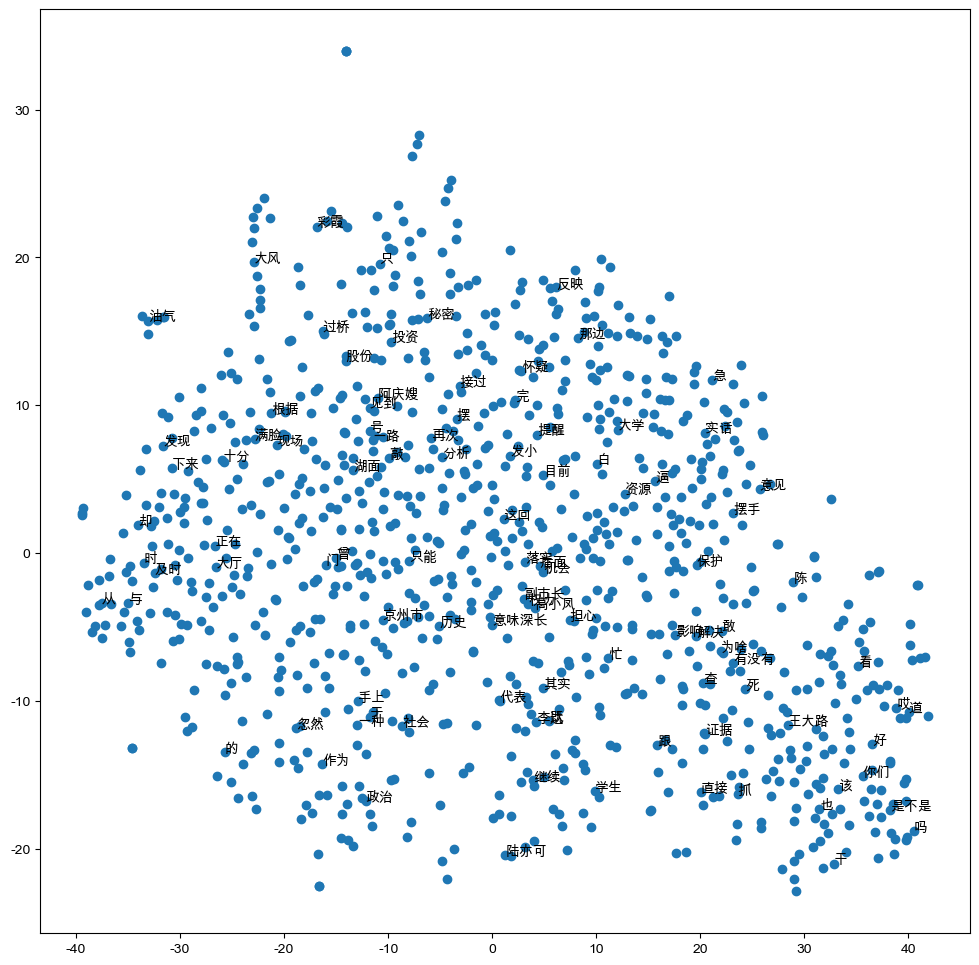

In [61]:
plot_with_matplotlib(x_vals, y_vals, labels)